## Introduction

The principle code used for this notebook was written by Kathyrn Ledbetter to demonstrate PID controls to Physics 113 students on Fall 2022. The first example is entirely coded by Kathryn Ledbetter and the second example is implemented by Ali Kurmus on July 2025 inspired by the first example. The code comments and markdown explanations are added by Ali Kurmus. Ali Kurmus acknowledges the use of GPT-4 to add further instructions and package dependencies to use interactive tools on Python. The first example shows how D gain can help, and the second example shows how I gain can help. The writers are still in the process of figuring out a full PID dependence. Some explanations show Ali Kurmus hoped the simulations would work in ideal cases but do not show the expected behaviour.

In [1]:
%matplotlib widget
import ipywidgets as widgets
print("widgets:", widgets.__version__)


widgets: 8.1.8


# PID Control Simulation: Velocity Regulation Example

This notebook simulates a basic velocity control problem using a PID (Proportional–Integral–Derivative) controller. The physical setup is akin to a car driving along a road, where drag and disturbance forces act against the vehicle’s motion.

The system is governed by the equation:


$\frac{dv}{dt} = a(t) - \beta v(t) - D(t)$


where:
- $v(t) $ is the vehicle’s velocity,
- $ a(t) $ is the throttle or control input (accelerator),
- $ \beta $ is a drag coefficient (air resistance),
- $ D(t) $ is an optional external disturbance (e.g. slope of a hill).

The goal of the PID controller is to drive the system’s output $ v(t) $ to follow a desired **setpoint** velocity $ v_{\text{sp}}(t) $, even in the presence of drag and disturbances.

---

## What Is a PID Controller?

A PID controller adjusts the input $ a(t) $ based on three components of the **error** $ e(t) = v(t) - v_{\text{sp}}(t) $:

- **Proportional (P):** Reacts to the current error.
- **Integral (I):** Reacts to the accumulated error over time.
- **Derivative (D):** Reacts to how quickly the error is changing.

The correction is computed as:


$a(t) = - k_P  e(t) + k_D \frac{de}{dt} + k_I \int e(t) dt$


Each component has its own gain: $k_P$, $k_I$, $k_D$.

---

## What Is the Setpoint?

The **setpoint**  $v_{\text{sp}}(t)$ is the target value that we want the system to follow. In this simulation, the setpoint starts at 5 m/s, drops to 3 m/s in the middle, then returns to 5 m/s. This creates a clear step-change that tests how the controller responds to dynamic targets.

---

## What Is the Error Signal?

The **error signal** is defined as:


$e(t) = v(t) - v_{\text{sp}}(t)$


It represents the difference between the current velocity and the desired velocity. The controller’s entire job is to reduce this error to zero using the throttle input.

---

## Why Plot the Error with the Accelerator Input?

One subplot in this simulation displays both the **error** $ e(t) $ (blue line) and the **accelerator input** $ a(t)/10 $ (red line, scaled for visibility). Plotting these together helps demonstrate the **cause-effect relationship** of the control loop:

- When the error increases, the accelerator reacts.
- If the error is persistent (e.g. due to a hill), the controller applies more throttle.
- The proportional term causes an immediate reaction.
- The derivative term anticipates the slope of the error.
- The integral term continues applying correction if the error does not decay.

Overlaying both signals helps illustrate how control inputs are driven by feedback — a central concept in control systems.

---

## Educational Value

This simulation is ideal for teaching PID concepts:

- **Tuning Practice:** Students can interactively adjust $ k_P, k_I, k_D $ to see their effects in real-time.
- **Overshoot and Damping:** Demonstrates how D helps damp responses and how P affects rise time.
- **Steady-State Error:** Shows that P alone cannot eliminate offset in the presence of disturbances — motivating the need for I.
- **Integral Wind-Up:** Demonstrates how integrator values can grow excessively when actuator limits are reached, causing overshoot when the setpoint changes back.

This is a general and transferable example of PID control, applicable to real-world systems like vehicle speed regulation, temperature control, motor drives, and more. Note that it is hard to create a situation where the integral term is necessary. The notebook works well for P and D. It is also good for demonstrating integral wind up.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
# Use the “widget” backend so that matplotlib plots become interactive
# (pan/zoom + live updates). Requires the ipympl package.
%matplotlib widget

import ipywidgets as widgets   # for the slider controls

---

## Demonstrations You Can Try

These scenarios demonstrate how different PID terms behave and why each is important.

### 1. Pure P Control vs. P + D Control

#### Pure P (Proportional Only)
- Set `kI = 0`, `kD = 0`, and choose a moderate `kP` (e.g. 1 to 5).
- The controller will react to the error proportionally, but:
  - You will observe **overshoot** when the setpoint changes.
  - The system will **settle at a velocity different from the setpoint** due to constant drag or disturbance.
- This steady-state error occurs because P alone cannot "push" hard enough without error being present.
- **Demo**: Drag the sliders to `kI = 0`, `kD = 0`, and increase `kP`. Run the simulation and observe the overshoot and residual offset after the step at `t = 0.5`.

#### P + D (Proportional + Derivative)
- Set `kD > 0` (e.g. 0.1–0.5) while keeping `kI = 0`.
- You'll notice:
  - **Reduced overshoot**
  - **Slower but more stable convergence**
- The derivative term reacts to the rate of change of the error and **damps fast movements**.
- **Demo**: With `kI = 0`, try increasing `kD` from 0 to 0.05. Watch how the purple "D" line activates strongly at transitions, and how the velocity overshoot decreases.

---

### 2. Why and When You Need the Integral Term (I) (I am not sure about this part)

#### Eliminating Steady-State Error
- When there's a constant disturbance (e.g. drag or slope), **P or PD alone cannot reach the setpoint**.
- The controller must settle with some error $ e > 0 $ so that the P-term provides a sustained correction.
- The **I-term accumulates this error over time**, pushing the throttle further until the error vanishes.




interactive(children=(FloatSlider(value=1.0, description='kP', max=10.0), FloatSlider(value=0.0, description='…

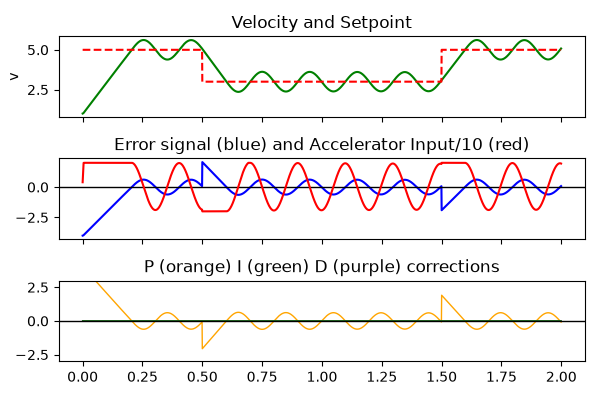

In [3]:
# ——————————————————————————————————————————
# Simulation parameters
# ——————————————————————————————————————————

npoints = 2000
# Create a “setpoint” velocity profile: start at 5 m/s, drop to 3 m/s
# between indices 500 and 1500
setpoint = np.ones(npoints) * 5
setpoint[500:1500] = 3

# This global will hold the “throttle” or accelerator command
a = 0

def drive_with_drag(v, a, i, beta, disturb):
    """
    Right‑hand side of dv/dt = a − β v − disturbance.
    v       : current velocity
    a       : accelerator input (global throttle)
    i       : time‑step index, used to index the disturbance
    beta    : drag coefficient
    disturb : array of extra “hill” or disturbance force
    """
    return a - beta * v - disturb[i]

# time step
dt = 0.001
# how often (in steps) to update the PID correction
delay = 1

def integrate_solution(
    func,               # the dynamics function, here drive_with_drag
    gain,               # tuple (kP, kI, kD)
    lim,                # absolute limit on the throttle a
    v0,                 # initial velocity
    dt,
    args,               # extra args to func (beta, disturbance array)
    n=npoints,
    integrate_forever=True,
    nintegrate=50,
    positive_only=False
):
    """
    Runs the time‑marching simulation, applying a PID loop to control v → setpoint.

    Returns:
      t       : time array
      v       : velocity at each step
      errs    : error = v – setpoint
      corrs   : the P, D, I components at each step
      a_vec   : the throttle history
    """
    global a, delay
    kP, kI, kD = gain

    # time vector
    t = np.arange(0, n * dt, dt)
    v = np.zeros_like(t)
    errs = np.zeros_like(t)
    corrs = np.zeros((len(t), 3))  # columns for P, D, I
    a_vec = np.zeros_like(t)

    v[0] = v0

    for i, timestep in enumerate(t):
        # 1) Compute error terms
        err = v[i] - setpoint[i]
        errs[i] = err

        # derivative of error (approximate)
        if i == 0:
            diff_err = 0
        else:
            diff_err = (v[i] - v[i - 1]) / dt

        # integral of error
        if integrate_forever:
            int_err = np.sum(errs[: i + 1]) * dt
        else:
            start = max(0, i - nintegrate)
            int_err = np.sum(errs[start : i + 1]) * dt

        # 2) Apply PID correction at the specified delay
        if i % delay == 0:
            correction = kP * err + kD * diff_err + kI * int_err
            # store component contributions for plotting
            corrs[i, 0] = kP * err
            corrs[i, 1] = kD * diff_err
            corrs[i, 2] = kI * int_err

            # adjust the global accelerator command
            a -= correction

        # 3) enforce throttle limits
        a = np.clip(a, -lim, lim)
        if positive_only and a < 0:
            a = 0

        a_vec[i] = a

        # 4) step the dynamics forward
        dvdt = func(v[i], a, i, *args)
        if i < n - 1:
            v[i + 1] = v[i] + dvdt * dt

    return t, v, errs, corrs, a_vec


# ——————————————————————————————————————————
# Initial PID gains & physical parameters
# ——————————————————————————————————————————
kP, kI, kD = 0.5, 0.0, 0.0
lim = 20
v0 = 5
beta = 0.1  # drag coefficient

# ——————————————————————————————————————————
# Set up the 3‑panel figure once, for reuse
# ——————————————————————————————————————————
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(6, 4))
axs[0].set_title('Velocity and Setpoint')
axs[1].set_title('Error signal (blue) and Accelerator Input/10 (red)')
axs[2].set_title('P (orange) I (green) D (purple) corrections')

# ——————————————————————————————————————————
# Interactive slider hook
# ——————————————————————————————————————————
@widgets.interact(
    kP=(0, 10, 0.1),
    kI=(0, 10, 0.1),
    kD=(0, 0.5, 0.001),
    limit=(0, 50, 5),
    v0=(-5, 5, 1),
    air_resistance=(0, 5, 0.1),
    hill_steepness=(0, 50, 1),
)
def update(
    kP=1.0,
    kI=0,
    kD=0,
    limit=20,
    v0=1,
    air_resistance=0.1,
    hill_steepness=0,
):
    # Clear old lines
    for ax in axs:
        for line in list(ax.lines):   # make a real list copy
            line.remove()

    # build a flat “hill” disturbance of constant steepness
    hill = np.ones(npoints) * hill_steepness

    # rerun the simulation with the new parameters
    t, v, err, corr, a_vec = integrate_solution(
        drive_with_drag,
        (kP, kI, kD),
        limit,
        v0,
        dt,
        args=(air_resistance, hill),
        positive_only=False,
    )

    # Plot results
    axs[0].plot(t, v, color='green', label='Velocity')
    axs[0].plot(t, setpoint, '--r', label='Setpoint')
    axs[0].set_ylabel('v')

    axs[1].plot(t, err, 'b')
    axs[1].axhline(0, color='k', linewidth=1)
    axs[1].plot(t, a_vec / 10, 'r')

    axs[2].plot(t, -corr[:, 0], color='orange',   linewidth=1)
    axs[2].plot(t, -corr[:, 1], color='purple',   linewidth=1)
    axs[2].plot(t, -corr[:, 2], color='green',    linewidth=1)
    axs[2].axhline(0, color='k', linewidth=1)
    axs[2].set_ylim([-3, 3])

    plt.tight_layout()


## Results of adding D

In [ ]:
# ——————————————————————————————————————————
# Simulation parameters
# ——————————————————————————————————————————

npoints = 2000
# Create a “setpoint” velocity profile: start at 5 m/s, drop to 3 m/s
# between indices 500 and 1500
setpoint = np.ones(npoints) * 5
setpoint[500:1500] = 3

# This global will hold the “throttle” or accelerator command
a = 0

def drive_with_drag(v, a, i, beta, disturb):
    """
    Right‑hand side of dv/dt = a − β v − disturbance.
    v       : current velocity
    a       : accelerator input (global throttle)
    i       : time‑step index, used to index the disturbance
    beta    : drag coefficient
    disturb : array of extra “hill” or disturbance force
    """
    return a - beta * v - disturb[i]

# time step
dt = 0.001
# how often (in steps) to update the PID correction
delay = 1

def integrate_solution(
    func,               # the dynamics function, here drive_with_drag
    gain,               # tuple (kP, kI, kD)
    lim,                # absolute limit on the throttle a
    v0,                 # initial velocity
    dt,
    args,               # extra args to func (beta, disturbance array)
    n=npoints,
    integrate_forever=True,
    nintegrate=50,
    positive_only=False
):
    """
    Runs the time‑marching simulation, applying a PID loop to control v → setpoint.

    Returns:
      t       : time array
      v       : velocity at each step
      errs    : error = v – setpoint
      corrs   : the P, D, I components at each step
      a_vec   : the throttle history
    """
    global a, delay
    kP, kI, kD = gain

    # time vector
    t = np.arange(0, n * dt, dt)
    v = np.zeros_like(t)
    errs = np.zeros_like(t)
    corrs = np.zeros((len(t), 3))  # columns for P, D, I
    a_vec = np.zeros_like(t)

    v[0] = v0

    for i, timestep in enumerate(t):
        # 1) Compute error terms
        err = v[i] - setpoint[i]
        errs[i] = err

        # derivative of error (approximate)
        if i == 0:
            diff_err = 0
        else:
            diff_err = (v[i] - v[i - 1]) / dt

        # integral of error
        if integrate_forever:
            int_err = np.sum(errs[: i + 1]) * dt
        else:
            start = max(0, i - nintegrate)
            int_err = np.sum(errs[start : i + 1]) * dt

        # 2) Apply PID correction at the specified delay
        if i % delay == 0:
            correction = kP * err + kD * diff_err + kI * int_err
            # store component contributions for plotting
            corrs[i, 0] = kP * err
            corrs[i, 1] = kD * diff_err
            corrs[i, 2] = kI * int_err

            # adjust the global accelerator command
            a -= correction

        # 3) enforce throttle limits
        a = np.clip(a, -lim, lim)
        if positive_only and a < 0:
            a = 0

        a_vec[i] = a

        # 4) step the dynamics forward
        dvdt = func(v[i], a, i, *args)
        if i < n - 1:
            v[i + 1] = v[i] + dvdt * dt

    return t, v, errs, corrs, a_vec


# ——————————————————————————————————————————
# Initial PID gains & physical parameters
# ——————————————————————————————————————————
kP, kI, kD = 0.5, 0.0, 0.0
lim = 20
v0 = 5
beta = 0.1  # drag coefficient

# ——————————————————————————————————————————
# Set up the 3‑panel figure once, for reuse
# ——————————————————————————————————————————
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(6, 4))
axs[0].set_title('Velocity and Setpoint')
axs[1].set_title('Error signal (blue) and Accelerator Input/10 (red)')
axs[2].set_title('P (orange) I (green) D (purple) corrections')

# ——————————————————————————————————————————
# Interactive slider hook
# ——————————————————————————————————————————
@widgets.interact(
    kP=(0, 10, 0.1),
    kI=(0, 10, 0.1),
    kD=(0, 0.5, 0.001),
    limit=(0, 50, 5),
    v0=(-5, 5, 1),
    air_resistance=(0, 5, 0.1),
    hill_steepness=(0, 50, 1),
)
def update(
    kP=1.0,
    kI=0,
    kD=0,
    limit=20,
    v0=1,
    air_resistance=0.1,
    hill_steepness=0,
):
    # Clear old lines
    for ax in axs:
        for line in list(ax.lines):   # make a real list copy
            line.remove()

    # build a flat “hill” disturbance of constant steepness
    hill = np.ones(npoints) * hill_steepness

    # rerun the simulation with the new parameters
    t, v, err, corr, a_vec = integrate_solution(
        drive_with_drag,
        (kP, kI, kD),
        limit,
        v0,
        dt,
        args=(air_resistance, hill),
        positive_only=False,
    )

    # Plot results
    axs[0].plot(t, v, color='green', label='Velocity')
    axs[0].plot(t, setpoint, '--r', label='Setpoint')
    axs[0].set_ylabel('v')

    axs[1].plot(t, err, 'b')
    axs[1].axhline(0, color='k', linewidth=1)
    axs[1].plot(t, a_vec / 10, 'r')

    axs[2].plot(t, -corr[:, 0], color='orange',   linewidth=1)
    axs[2].plot(t, -corr[:, 1], color='purple',   linewidth=1)
    axs[2].plot(t, -corr[:, 2], color='green',    linewidth=1)
    axs[2].axhline(0, color='k', linewidth=1)
    axs[2].set_ylim([-3, 3])

    plt.tight_layout()


Further testing to get a system that requires PID. I am not sure if I will be able to do it.
# PID Control Simulation: Heating a Room with Thermal Loss

This simulation models a basic heating system where a controller adjusts the **heater power** to maintain a target **room temperature** in the presence of constant **heat loss** to the environment. This can also be a case of how removing D may make things better.

---

## 🌡️ Physical Model

The temperature $ T(t) $ evolves according to:

$
\frac{dT}{dt} = a(t) - k_{\text{loss}}(T - T_{\text{env}})
$

Where:
- $ a(t) $: Power applied by the heater (control input)
- $ k_{\text{loss}} $: Heat loss rate (depends on insulation quality)
- $ T_{\text{env}} $: Ambient temperature (e.g., 15 °C)

The goal is to make the room follow a desired **setpoint temperature** over time — even as that target changes.

---

## 🎯 PID Controller

The controller minimizes the error:

$
e(t) = T(t) - T_{\text{setpoint}}(t)
$

It computes the heater power from:

$
a(t) = - k_P e(t) + k_D \frac{de}{dt} + k_I \int e(t) dt
$

Where:
- **P (Proportional)** reacts to the current error
- **I (Integral)** accumulates past error to eliminate steady-state offset
- **D (Derivative)** anticipates change and damps overshoot

---

## Why This Is a Good Example for I-Term

- A **proportional-only controller** cannot fully overcome heat loss, so the room settles **below the setpoint**.
- The **integral term** is required to drive the long-term error to zero and **reach the exact target** temperature.
- (In Theory) The **derivative term** becomes more useful when the setpoint changes quickly — it can help prevent overshoot and stabilize rapid heating.

---

## Visualization

The notebook displays:
1. **Temperature vs. Setpoint** — shows whether tracking is accurate.
2. **Error and Heater Power** — shows how error drives the controller.
3. **P, I, D Contributions** — illustrates how each term affects control.

Use the sliders to:
- Adjust PID gains
- Tune heat loss rate
- Try various limits on heater power
- Explore system dynamics and controller behavior

---

## Suggested Experiments

- Set `kI = 0` and observe that temperature **never reaches the setpoint**.
- Add `kI > 0` and see how the room slowly reaches the target temperature.
- (Currently not working) Add `kD` and observe how **overshoot is reduced** during step changes in the setpoint.


In [ ]:
npoints = 4000
dt = 0.01
setpoint = np.ones(npoints) * 22
setpoint[1000:2000] = 26
setpoint[2000:] = 20

env_temp = 15  # degrees C

a = 0  # heater power

def heat_dynamics(T, a, i, loss_rate):
    """
    Heating system dynamics:
    dT/dt = heating_power - heat_loss
    """
    heat_loss = loss_rate * (T - env_temp)
    return a - heat_loss

def integrate_solution(func, gain, lim, T0, dt, args,
                       n=npoints, integrate_forever=True, nintegrate=50):
    global a
    kP, kI, kD = gain
    t = np.arange(0, n * dt, dt)
    T = np.zeros_like(t)
    errs = np.zeros_like(t)
    corrs = np.zeros((len(t), 3))
    a_vec = np.zeros_like(t)
    T[0] = T0

    for i in range(len(t)):
        err = T[i] - setpoint[i]
        errs[i] = err
        diff_err = 0 if i == 0 else (T[i] - T[i-1]) / dt
        int_err = np.sum(errs[:i+1]) * dt if integrate_forever else np.sum(errs[max(0,i-nintegrate):i+1]) * dt

        correction = kP * err + kD * diff_err + kI * int_err
        corrs[i] = [kP * err, kD * diff_err, kI * int_err]
        a = -correction

        a = np.clip(a, 0, lim)
        a_vec[i] = a
        dTdt = func(T[i], a, i, *args)
        if i < len(T) - 1:
            T[i+1] = T[i] + dTdt * dt

    return t, T, errs, corrs, a_vec

# Plot setup
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(6, 4))
axs[0].set_title('Temperature and Setpoint')
axs[1].set_title('Error (blue) and Heater Power (red)')
axs[2].set_title('P (orange), I (green), D (purple) corrections')

@widgets.interact(
    kP=(0, 10, 0.1),
    kI=(0, 2.0, 0.05),
    kD=(0, 1.0, 0.01),
    limit=(0, 50, 1),
    T0=(10, 25, 0.5),
    loss_rate=(0.01, 0.5, 0.01)
)
def update(kP=1.0, kI=0.2, kD=0.2, limit=30, T0=15, loss_rate=0.1):
    for ax in axs:
        for line in list(ax.lines):
            line.remove()

    t, T, err, corr, a_vec = integrate_solution(
        heat_dynamics, (kP, kI, kD), limit, T0, dt,
        args=(loss_rate,), integrate_forever=True
    )

    axs[0].plot(t, T, color='red', label='Temp')
    axs[0].plot(t, setpoint, '--k', label='Setpoint')
    axs[0].set_ylabel('T (°C)')

    axs[1].plot(t, err, 'blue')
    axs[1].plot(t, a_vec, 'red')
    axs[1].axhline(0, color='k', linewidth=0.5)

    axs[2].plot(t, -corr[:, 0], color='orange')
    axs[2].plot(t, -corr[:, 1], color='purple')
    axs[2].plot(t, -corr[:, 2], color='green')
    axs[2].axhline(0, color='k', linewidth=0.5)
    axs[2].set_ylim([-5, 5])
    plt.tight_layout()


## Results of adding I

In [ ]:
npoints = 4000
dt = 0.01
setpoint = np.ones(npoints) * 22
setpoint[1000:2000] = 26
setpoint[2000:] = 20

env_temp = 15  # degrees C

a = 0  # heater power

def heat_dynamics(T, a, i, loss_rate):
    """
    Heating system dynamics:
    dT/dt = heating_power - heat_loss
    """
    heat_loss = loss_rate * (T - env_temp)
    return a - heat_loss

def integrate_solution(func, gain, lim, T0, dt, args,
                       n=npoints, integrate_forever=True, nintegrate=50):
    global a
    kP, kI, kD = gain
    t = np.arange(0, n * dt, dt)
    T = np.zeros_like(t)
    errs = np.zeros_like(t)
    corrs = np.zeros((len(t), 3))
    a_vec = np.zeros_like(t)
    T[0] = T0

    for i in range(len(t)):
        err = T[i] - setpoint[i]
        errs[i] = err
        diff_err = 0 if i == 0 else (T[i] - T[i-1]) / dt
        int_err = np.sum(errs[:i+1]) * dt if integrate_forever else np.sum(errs[max(0,i-nintegrate):i+1]) * dt

        correction = kP * err + kD * diff_err + kI * int_err
        corrs[i] = [kP * err, kD * diff_err, kI * int_err]
        a = -correction

        a = np.clip(a, 0, lim)
        a_vec[i] = a
        dTdt = func(T[i], a, i, *args)
        if i < len(T) - 1:
            T[i+1] = T[i] + dTdt * dt

    return t, T, errs, corrs, a_vec

# Plot setup
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(6, 4))
axs[0].set_title('Temperature and Setpoint')
axs[1].set_title('Error (blue) and Heater Power (red)')
axs[2].set_title('P (orange), I (green), D (purple) corrections')

@widgets.interact(
    kP=(0, 10, 0.1),
    kI=(0, 2.0, 0.05),
    kD=(0, 1.0, 0.01),
    limit=(0, 50, 1),
    T0=(10, 25, 0.5),
    loss_rate=(0.01, 0.5, 0.01)
)
def update(kP=1.0, kI=0.2, kD=0.2, limit=30, T0=15, loss_rate=0.1):
    for ax in axs:
        for line in list(ax.lines):
            line.remove()

    t, T, err, corr, a_vec = integrate_solution(
        heat_dynamics, (kP, kI, kD), limit, T0, dt,
        args=(loss_rate,), integrate_forever=True
    )

    axs[0].plot(t, T, color='red', label='Temp')
    axs[0].plot(t, setpoint, '--k', label='Setpoint')
    axs[0].set_ylabel('T (°C)')

    axs[1].plot(t, err, 'blue')
    axs[1].plot(t, a_vec, 'red')
    axs[1].axhline(0, color='k', linewidth=0.5)

    axs[2].plot(t, -corr[:, 0], color='orange')
    axs[2].plot(t, -corr[:, 1], color='purple')
    axs[2].plot(t, -corr[:, 2], color='green')
    axs[2].axhline(0, color='k', linewidth=0.5)
    axs[2].set_ylim([-5, 5])
    plt.tight_layout()
